In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('./data.csv', header=None)

data.head(3)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [2]:
data = data.drop(columns=0) # drop id column
data.describe()

,2,3,4,5,6,7,8,9,10,11,...,22,23,24,25,26,27,28,29,30,31
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [3]:
X = data.iloc[:,1:].values
y = (data[1] == 'M').astype(int).values.reshape(len(data), 1)
print(X.shape)
print(y.shape)

(569, 30)
(569, 1)


In [4]:
from microtorch.preprocessing import random_split, StandardScaler

(X_train, y_train), (X_test, y_test) = random_split(X, y, ratios=[0.8, 0.2], seed=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(456, 30)
(113, 30)
(456, 1)
(113, 1)


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.mean(axis=0))
print(X_train.std(axis=0))

[-4.00435046e-15 -1.08733685e-15 -1.29550367e-15 -1.23658393e-15
  9.20511231e-15 -8.74665837e-17 -7.92372990e-16  5.81893208e-16
 -6.13421046e-15  4.18037924e-15 -9.64141048e-16 -1.63980823e-16
 -6.01370805e-16 -7.86407976e-16 -1.20018518e-15 -1.09476268e-15
  7.82999396e-16 -2.16688266e-16  1.99447549e-15  4.18053141e-16
 -1.19032464e-15  3.08598176e-15 -1.05325105e-15  4.69166616e-16
  1.29911006e-15 -3.58996458e-16 -5.32225336e-16  1.20663713e-15
 -1.46349794e-15  2.32312951e-15]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [18]:
from microtorch import models
from microtorch.optimizers import SGD
from microtorch.functions import cross_entropy_loss

np.random.seed(0)

n_features = X.shape[1]

model = models.LogisticRegression(
    input_dim=n_features,
)

optimizer = SGD(model.parameters(), lr=1) # large learning rate since we have normalized the dataset

loss_fn = cross_entropy_loss

epochs = 50

loss_hist = []
train_acc_h = []
test_acc_h = []

y_pred_train = (model(X_train) > 0.5).astype(int)
y_pred_test = (model(X_test) > 0.5).astype(int)

train_acc = (y_train == y_pred_train).mean()
test_acc = (y_test == y_pred_test).mean()

print(f"Before Training: Train Accuracy {train_acc:.2f} | Test Accuracy {test_acc:.2f}")

for e in range(epochs):
    y_pred = model(X_train)
    l = loss_fn(y_pred, y_train)

    print(f"Epoch {e} Loss: {l}")

    l.backprop()
    optimizer.step()
    optimizer.zero_grad()

    # accuracy
    y_pred_train = (model(X_train) > 0.5).astype(int)
    y_pred_test = (model(X_test) > 0.5).astype(int)

    train_acc = (y_train == y_pred_train).mean()
    test_acc = (y_test == y_pred_test).mean()

    loss_hist.append(l.val)
    train_acc_h.append(train_acc)
    test_acc_h.append(test_acc)

    print(f"Epoch {e}: Train Accuracy {train_acc:.2f} | Test Accuracy {test_acc:.2f}")

Before Training: Train Accuracy 0.91 | Test Accuracy 0.93
Epoch 0 Loss: Grad(value = 0.1273664713434491, grad=0)
Epoch 0: Train Accuracy 0.91 | Test Accuracy 0.93
Epoch 1 Loss: Grad(value = 0.11924837163216587, grad=0)
Epoch 1: Train Accuracy 0.91 | Test Accuracy 0.93
Epoch 2 Loss: Grad(value = 0.11162992627869507, grad=0)
Epoch 2: Train Accuracy 0.91 | Test Accuracy 0.93
Epoch 3 Loss: Grad(value = 0.10451691257520337, grad=0)
Epoch 3: Train Accuracy 0.91 | Test Accuracy 0.93
Epoch 4 Loss: Grad(value = 0.0979073583763828, grad=0)
Epoch 4: Train Accuracy 0.91 | Test Accuracy 0.94
Epoch 5 Loss: Grad(value = 0.09179091129351967, grad=0)
Epoch 5: Train Accuracy 0.91 | Test Accuracy 0.96
Epoch 6 Loss: Grad(value = 0.08614941688646054, grad=0)
Epoch 6: Train Accuracy 0.91 | Test Accuracy 0.96
Epoch 7 Loss: Grad(value = 0.08095834635828544, grad=0)
Epoch 7: Train Accuracy 0.91 | Test Accuracy 0.96
Epoch 8 Loss: Grad(value = 0.07618863046911341, grad=0)
Epoch 8: Train Accuracy 0.92 | Test Accu

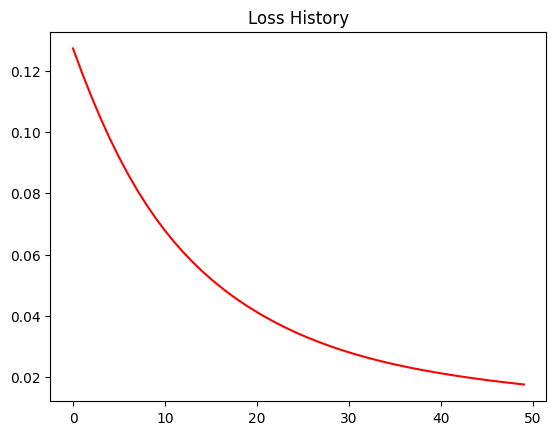

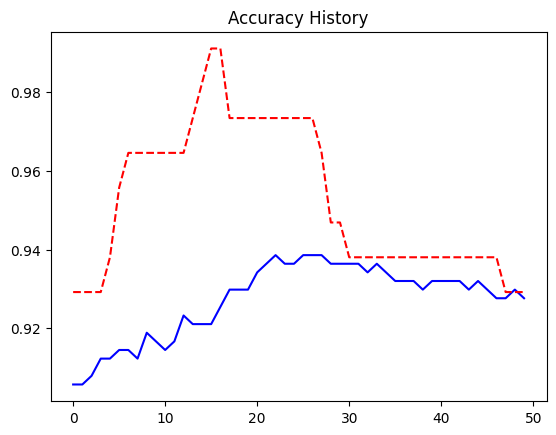

In [19]:
import matplotlib.pyplot as plt

eps = np.arange(epochs)

plt.title('Loss History')
plt.plot(eps, loss_hist, 'r-')
plt.show()

plt.title('Accuracy History')
plt.plot(eps, train_acc_h, 'b-', label='train acc')
plt.plot(eps, test_acc_h, 'r--', label='test acc')
plt.show()